## About Dataset :


Customer churn refers to the phenomenon where customers discontinue their relationship or subscription with a company or service provider. It represents the rate at which customers stop using a company's products or services within a specific period. Churn is an important metric for businesses as it directly impacts revenue, growth, and customer retention.

In the context of the Churn dataset, the churn label indicates whether a customer has churned or not. A churned customer is one who has decided to discontinue their subscription or usage of the company's services. On the other hand, a non-churned customer is one who continues to remain engaged and retains their relationship with the company.

Understanding customer churn is crucial for businesses to identify patterns, factors, and indicators that contribute to customer attrition. By analyzing churn behavior and its associated features, companies can develop strategies to retain existing customers, improve customer satisfaction, and reduce customer turnover. Predictive modeling techniques can also be applied to forecast and proactively address potential churn, enabling companies to take proactive measures to retain at-risk customers.

In [116]:
import pandas as pd
import numpy as np
import sklearn as sk
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats


In [ ]:
dataframe = pd.read_csv("../raw_data/customer_churn_dataset-training-master.csv")
df = dataframe.copy()



In [118]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [119]:
df.isnull().sum() #checking null values

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [120]:
df[df.isna().all(axis=1)] #this row is all null have no meaning so we may delete it

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [121]:
df.isna().all(axis=1).sum()

np.int64(1)

In [122]:
df.duplicated().sum()

np.int64(0)

In [123]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 40.4 MB


In [124]:
for col in df.select_dtypes(include="object"):
    print(f"\n{col}")
    print(df[col].value_counts())


Gender
Gender
Male      250252
Female    190580
Name: count, dtype: int64

Subscription Type
Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64

Contract Length
Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
Name: count, dtype: int64


/var/folders/mc/x59j3q5924sby1mf7q1fdslm0000gq/T/ipykernel_6890/4117860049.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


In [125]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [126]:
df["Churn"].value_counts(normalize=True)*100

Churn
1.0    56.71072
0.0    43.28928
Name: proportion, dtype: float64

In [127]:
df.dtypes

CustomerID           float64
Age                  float64
Gender                   str
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type        str
Contract Length          str
Total Spend          float64
Last Interaction     float64
Churn                float64
dtype: object

## Data Cleaninng


1- Cleaning the empty row becausse its not needed


In [128]:
df =df.dropna(how="all").reset_index(drop=True)

In [129]:
df.isna().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [130]:
df.shape

(440832, 12)

2.  Converting CustomerID, Age, Tenure, Usage Frequency, Support Calls, Payment Delay, and Last Interaction to integer type. Churn was also converted to integer because it is a binary variable. and str columns into categorical columns

In [131]:
# Integer columns
int_cols = ['CustomerID','Age','Tenure','Usage Frequency','Support Calls','Payment Delay','Last Interaction','Churn']

df[int_cols] = df[int_cols].astype("int64")

cat_cols = ['Gender','Subscription Type','Contract Length']
df[cat_cols] = df[cat_cols].astype('category')

In [132]:
df.dtypes

CustomerID              int64
Age                     int64
Gender               category
Tenure                  int64
Usage Frequency         int64
Support Calls           int64
Payment Delay           int64
Subscription Type    category
Contract Length      category
Total Spend           float64
Last Interaction        int64
Churn                   int64
dtype: object

In [133]:
df.sample(10)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
244723,251532,36,Female,24,7,0,5,Basic,Annual,875.35,7,1
421277,428393,47,Male,50,20,0,19,Standard,Annual,892.62,10,0
378975,386091,39,Female,56,23,1,2,Standard,Quarterly,781.62,14,0
39577,39920,64,Female,36,17,6,14,Premium,Monthly,898.00,13,1
244753,251562,43,Male,49,11,6,0,Premium,Monthly,970.98,29,1
157709,162520,50,Female,44,20,5,1,Standard,Quarterly,323.00,29,1
188679,193490,33,Male,52,3,4,21,Basic,Annual,438.00,29,1
113276,116824,53,Female,6,14,1,22,Premium,Monthly,753.00,15,1
99668,102624,56,Male,41,1,6,10,Premium,Annual,199.00,30,1
65864,67334,32,Female,38,7,8,17,Premium,Annual,648.00,24,1


## EDA

In [134]:
num_cols = [
    'Age',
    'Tenure',
    'Usage Frequency',
    'Payment Delay',
    'Total Spend',
    'Last Interaction',
    'Support Calls',
]

cat_cols = [
    'Gender',
    'Subscription Type',
    'Contract Length'
]

target = 'Churn'

<Axes: xlabel='Churn', ylabel='count'>

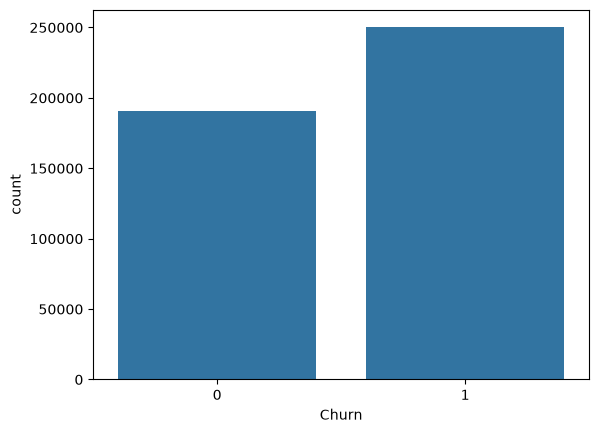

In [135]:
sns.countplot(data=df , x=target)

# Univariate analysis:

#### Numerical Columns

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Tenure'}>,
        <Axes: title={'center': 'Usage Frequency'}>],
       [<Axes: title={'center': 'Payment Delay'}>,
        <Axes: title={'center': 'Total Spend'}>,
        <Axes: title={'center': 'Last Interaction'}>],
       [<Axes: title={'center': 'Support Calls'}>, <Axes: >, <Axes: >]],
      dtype=object)

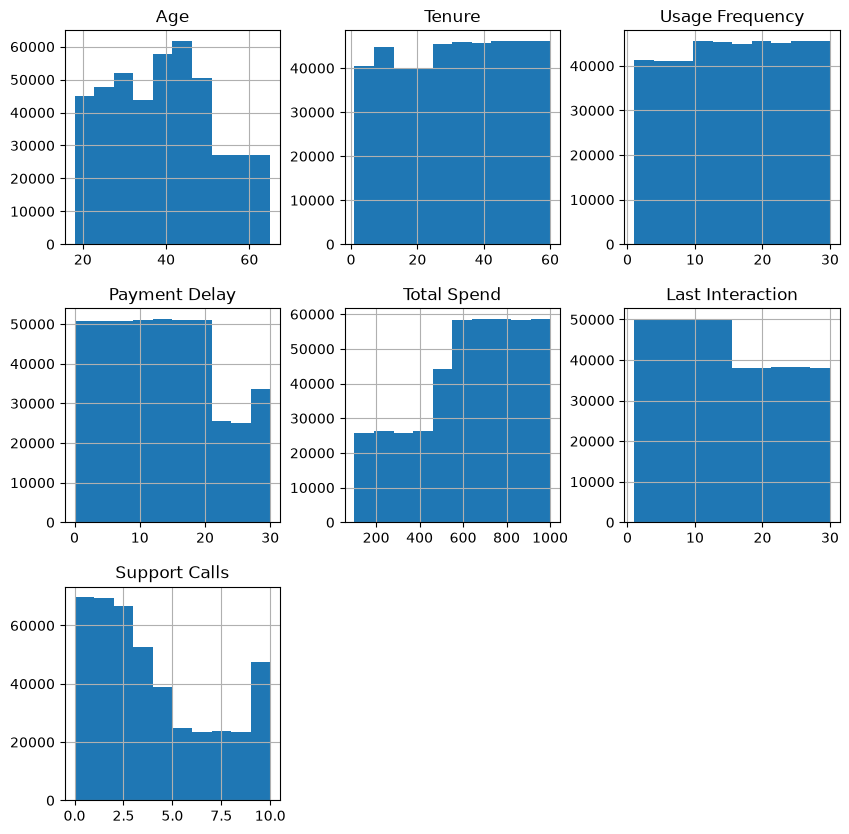

In [136]:
df[num_cols].hist(figsize=(10,10))

In [137]:
df[num_cols].skew().sort_values(ascending=False)

Support Calls       0.666809
Payment Delay       0.267407
Last Interaction    0.176774
Age                 0.162016
Usage Frequency    -0.043473
Tenure             -0.061402
Total Spend        -0.457174
dtype: float64

-  almost uniform distriution not much skewed

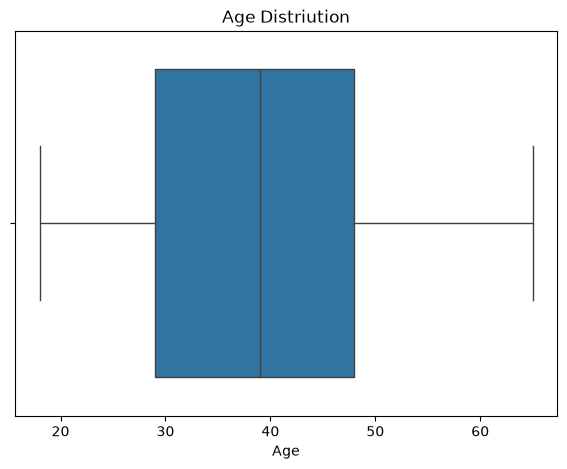

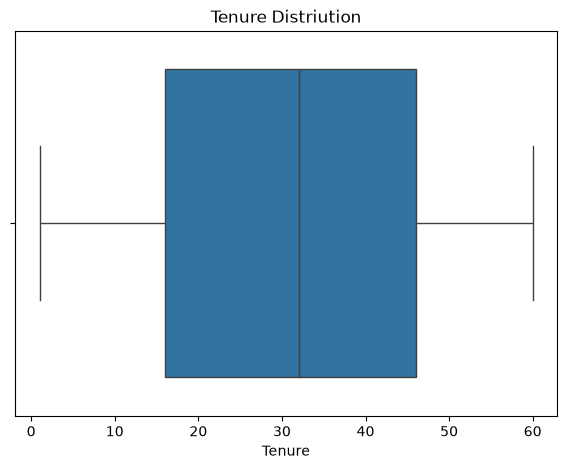

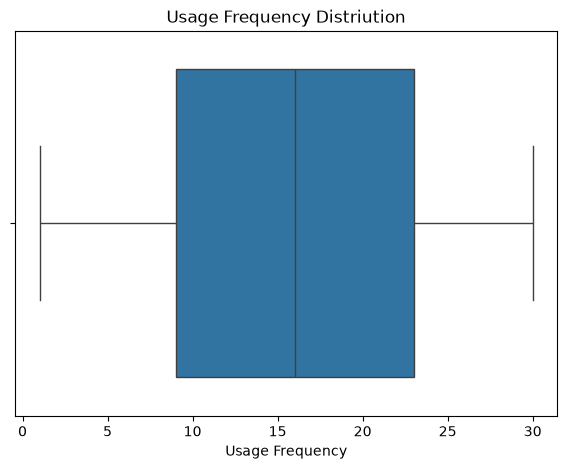

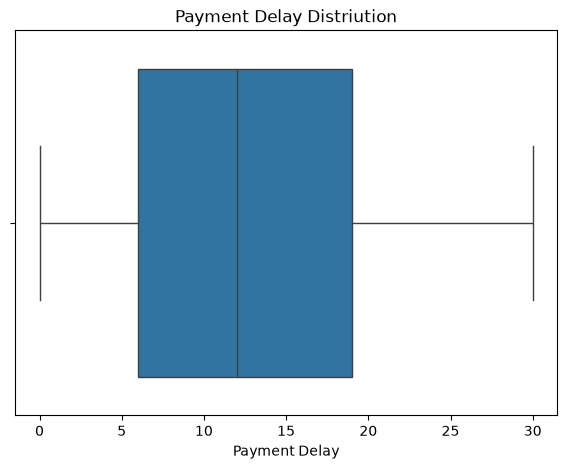

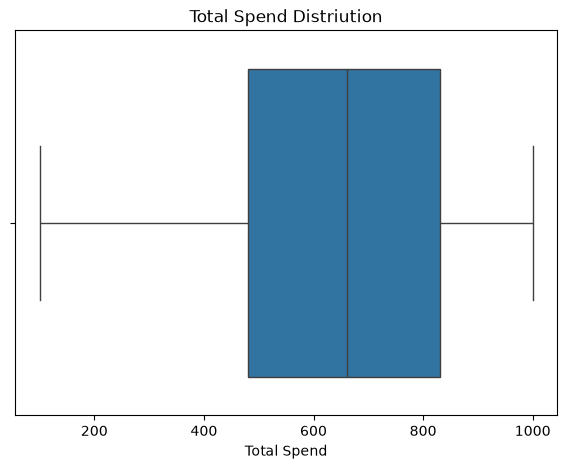

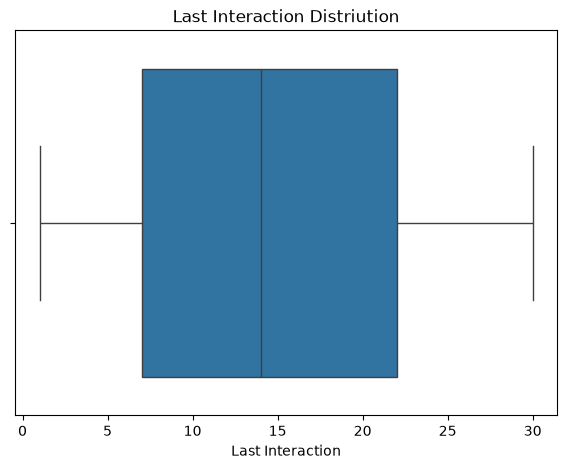

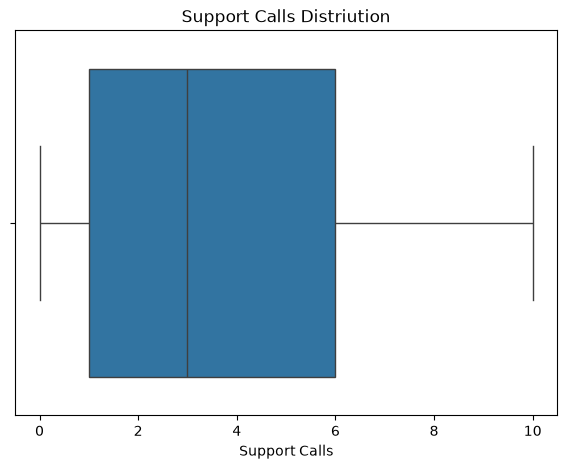

In [138]:
for col in num_cols:
    plt.figure(figsize=(7,5))
    sns.boxplot(data=df , x=col)
    plt.title(f"{col} Distriution")


#### Categorical columns

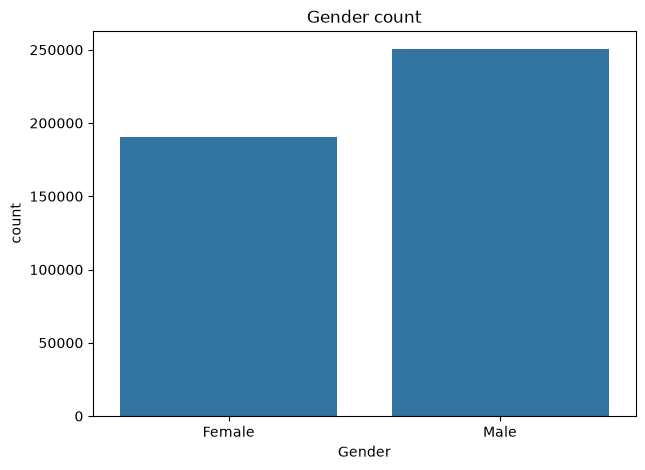

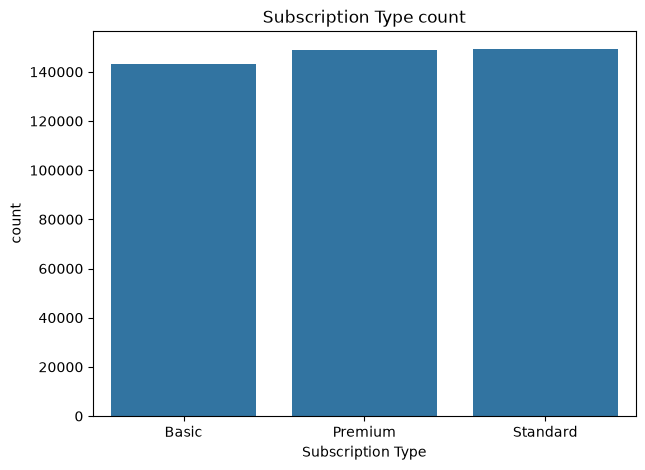

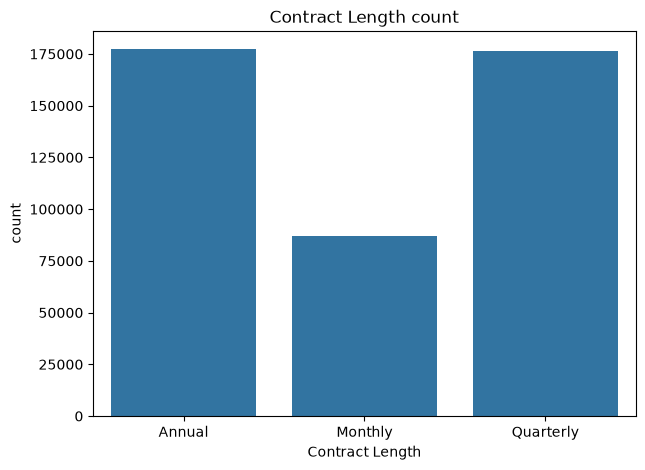

In [139]:
for col in cat_cols:
    plt.figure(figsize=(7,5))
    sns.countplot(data=df , x=col)
    plt.title(f"{col} count")
    plt.show()

In [140]:
df["Contract Length"].value_counts(normalize=True)*100 

Contract Length
Annual       40.196265
Quarterly    40.044734
Monthly      19.759001
Name: proportion, dtype: float64

- monthly conntract has only 19.7 percent distriution most data is around annual and Quartly lengths

# Bivariate Analysis

### Numerical vs target 

In [141]:
#performing t-test for nummerical vs target
for col in num_cols:
    churned = df[df["Churn"]==1][col]
    retained = df[df['Churn']==0][col]

    t_stat , p_value = stats.ttest_ind(churned , retained)
    print(f"{col:20s} | p-value : {p_value:2f} , {"Significant" if p_value < 0.05 else "Not Significant" }")

Age                  | p-value : 0.000000 , Significant
Tenure               | p-value : 0.000000 , Significant
Usage Frequency      | p-value : 0.000000 , Significant
Payment Delay        | p-value : 0.000000 , Significant
Total Spend          | p-value : 0.000000 , Significant
Last Interaction     | p-value : 0.000000 , Significant
Support Calls        | p-value : 0.000000 , Significant


 - Relation :  nummerical columns are significant means assuming they have strong relationshipp


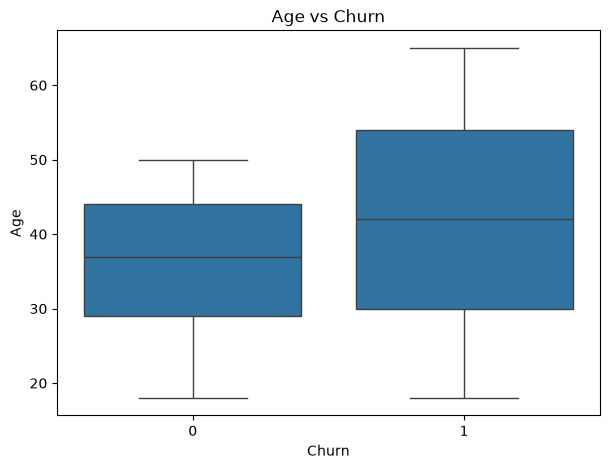

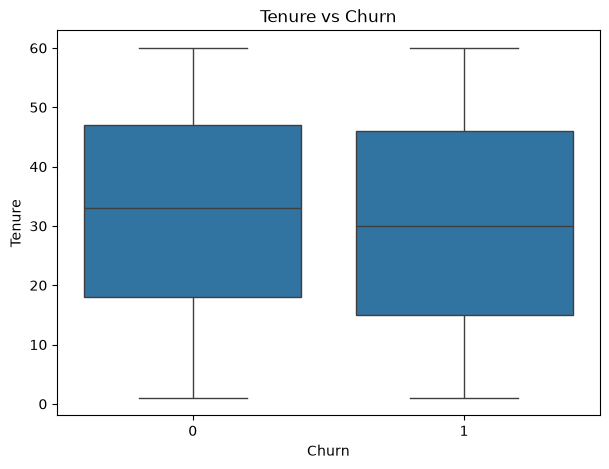

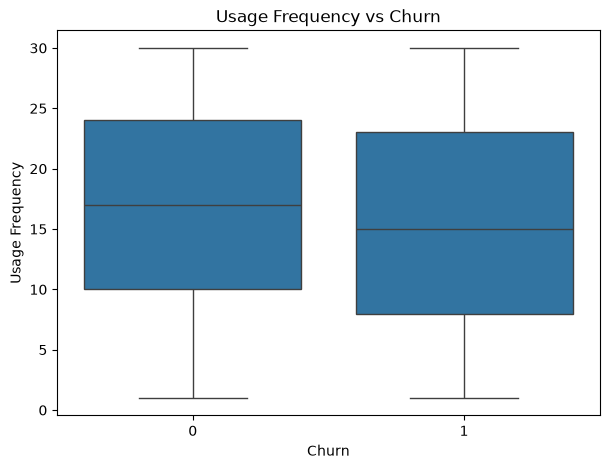

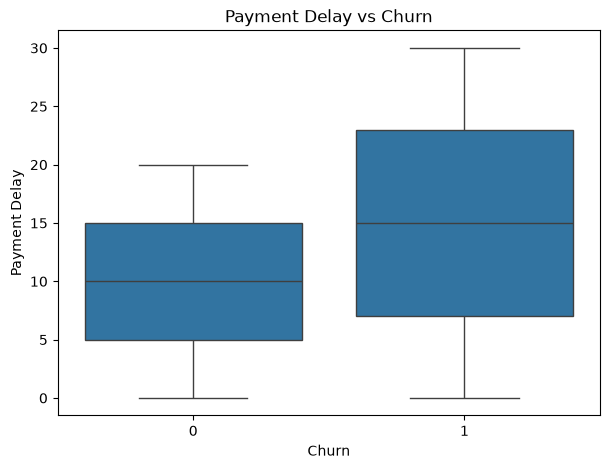

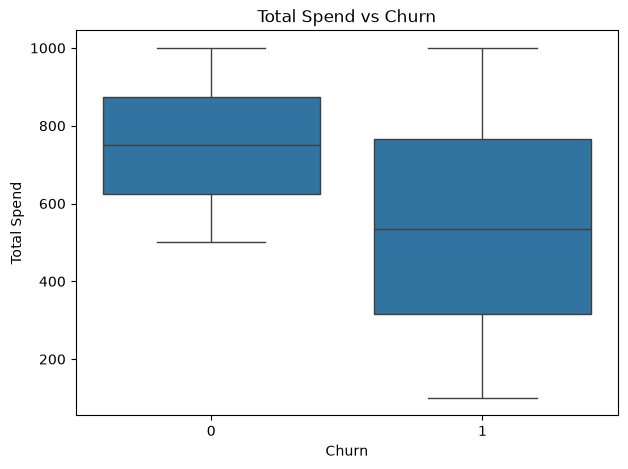

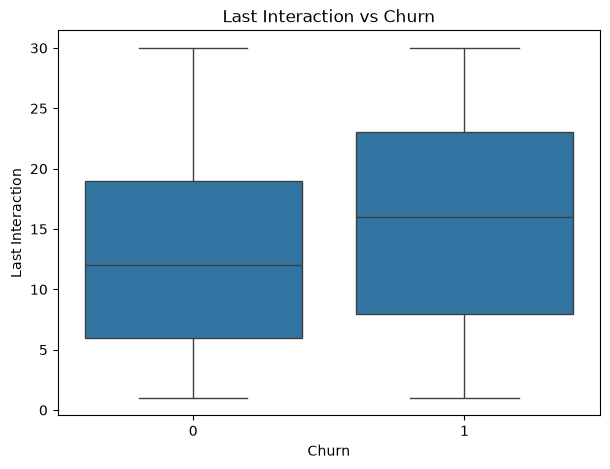

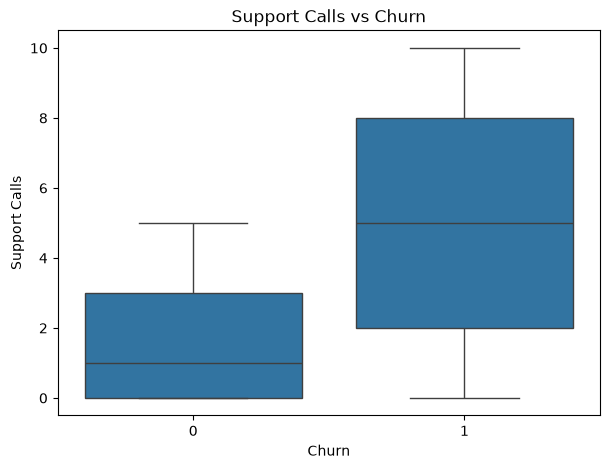

In [142]:
for col in num_cols:
    plt.figure(figsize=(7,5))
    sns.boxplot(data=df , x=target ,  y=col)
    plt.title(f"{col} vs {target}")
    plt.show

### Categorical vs target

In [143]:
from scipy.stats import chi2_contingency
for col in cat_cols:
    print("-"*40)
    print(f"{col} vs Churn")
    print("\n")

    #contigency table
    cross_tab = pd.crosstab(df[col] ,  df[target])
    print("\nCross tab")
    print(cross_tab)

    #chi-square test
    chi2 , p_value ,dof , expected = chi2_contingency(cross_tab)

    print(f"\nChi-square statistic: {chi2:.4f}")
    print(f"p-value: {p_value:.6f}")
    print(f"Degrees of freedom: {dof}")

    alpha = 0.05

    if p_value < 0.05 :
        print("Significant asscociation with churn. Reject Ho")
    else:
        print("NOT Significant asscociation with churn. Fail to reject Ho")


----------------------------------------
Gender vs Churn



Cross tab
Churn        0       1
Gender                
Female   63522  127058
Male    127311  122941

Chi-square statistic: 13560.7347
p-value: 0.000000
Degrees of freedom: 1
Significant asscociation with churn. Reject Ho
----------------------------------------
Subscription Type vs Churn



Cross tab
Churn                  0      1
Subscription Type              
Basic              59816  83210
Premium            65505  83173
Standard           65512  83616

Chi-square statistic: 186.2251
p-value: 0.000000
Degrees of freedom: 2
Significant asscociation with churn. Reject Ho
----------------------------------------
Contract Length vs Churn



Cross tab
Churn                0      1
Contract Length              
Annual           95552  81646
Monthly              0  87104
Quarterly        95281  81249

Chi-square statistic: 82862.3911
p-value: 0.000000
Degrees of freedom: 2
Significant asscociation with churn. Reject Ho


### observations:

1. Gender vs churn:  Females churn more as compare to Males

2. subscriptionn vs churn : They are almost similar but standard has slightly more churn rate as compare to baisc and. premium

3. Contract Length :  Montly contract has more. churnn rate

4. Support calls:  also have shown signifanct relation with target column





# corelation matrix 

In [144]:
df[num_cols + ['Churn']].corr()

,Age,Tenure,Usage Frequency,Payment Delay,Total Spend,Last Interaction,Support Calls,Churn
Age,1.000000,-0.011630,-0.007190,0.061738,-0.084684,0.028980,0.158451,0.218394
Tenure,-0.011630,1.000000,-0.026800,-0.016588,0.019006,-0.006903,-0.027640,-0.051919
Usage Frequency,-0.007190,-0.026800,1.000000,-0.014470,0.018631,-0.004662,-0.022013,-0.046101
Payment Delay,0.061738,-0.016588,-0.014470,1.000000,-0.121044,0.042708,0.162889,0.312129
Total Spend,-0.084684,0.019006,0.018631,-0.121044,1.000000,-0.056890,-0.221594,-0.429355
Last Interaction,0.028980,-0.006903,-0.004662,0.042708,-0.056890,1.000000,0.077684,0.149616
Support Calls,0.158451,-0.027640,-0.022013,0.162889,-0.221594,0.077684,1.000000,0.574267
Churn,0.218394,-0.051919,-0.046101,0.312129,-0.429355,0.149616,0.574267,1.000000


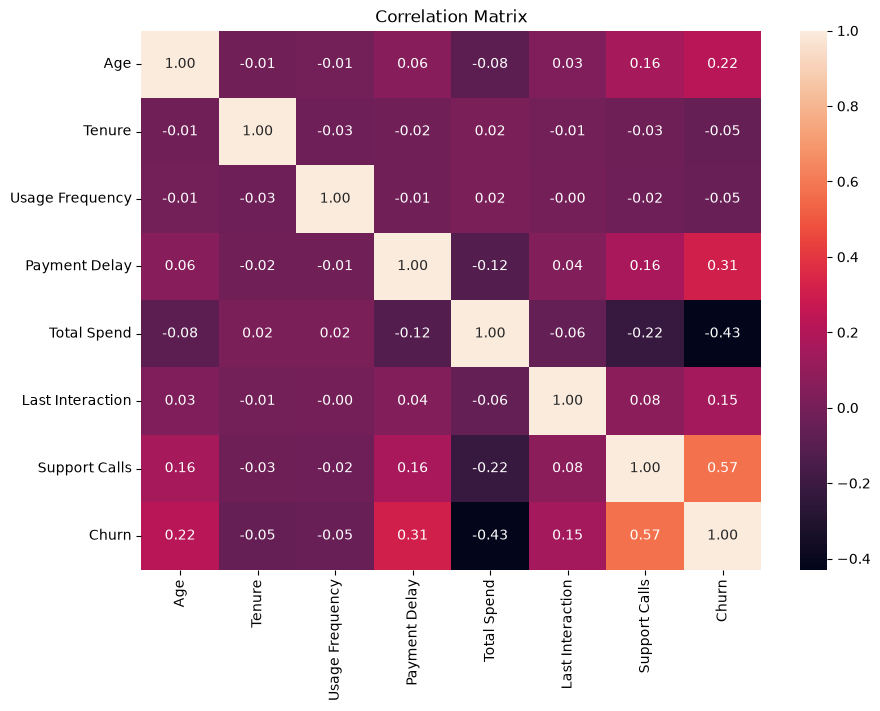

In [145]:
corr = df[num_cols + ['Churn']].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

In [146]:
df.sample(7)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
206306,211401,54,Female,7,2,4,7,Standard,Annual,886.51,1,1
96674,99513,23,Male,52,14,3,6,Standard,Annual,405.00,17,1
334213,341329,30,Male,44,18,2,5,Basic,Quarterly,663.04,10,0
127104,131220,39,Female,52,20,7,13,Premium,Monthly,724.00,29,1
318987,326103,31,Female,51,16,2,2,Premium,Annual,652.43,12,0
323566,330682,33,Male,22,20,0,8,Standard,Annual,752.63,11,0
28029,28038,52,Female,51,9,2,13,Premium,Annual,186.00,4,1


In [ ]:
df.to_csv("../processed_data/procesed_customer_churn.csv")

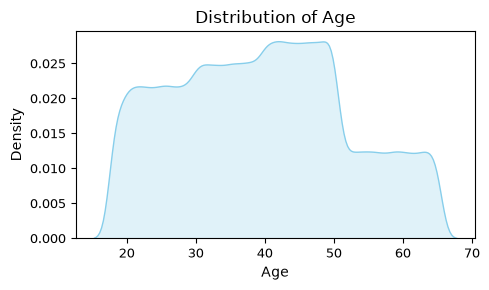

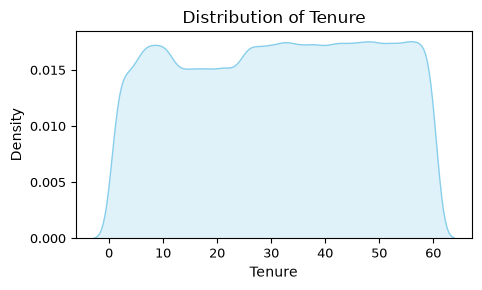

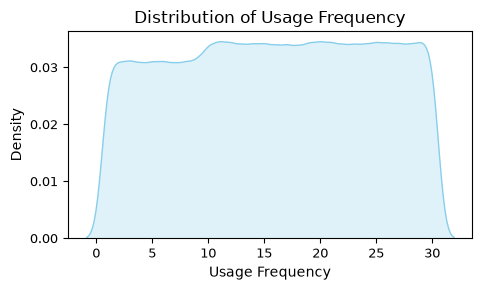

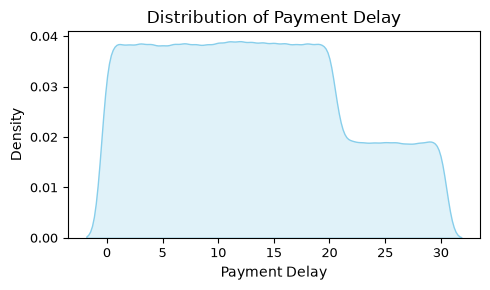

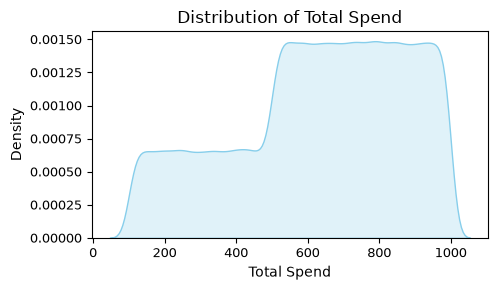

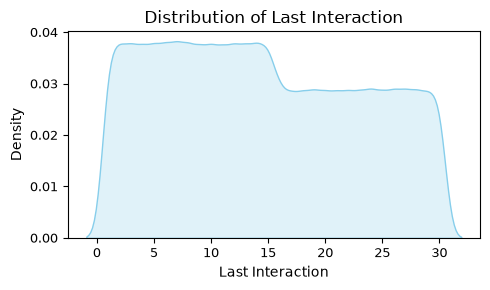

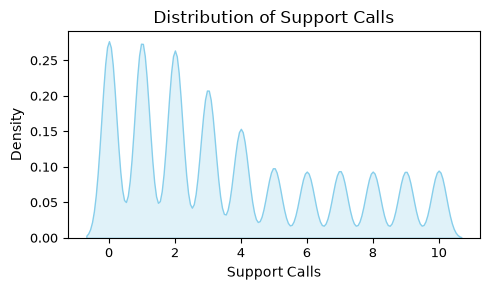

In [148]:
# Plot each numerical column
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.kdeplot(data=df, x=col, fill=True, color="skyblue")
    plt.title(f"Distribution of {col}", fontsize=12)
    plt.xlabel(col, fontsize=10)
    plt.ylabel("Density", fontsize=10)
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()         #numerical columns moslty have kinddd of uniform distriutionn


1. The data mostly follows the uniform Distribution
   , a min max scalar for nummerical columns may suitable

2. Age can be binned into age groups but I have leave them as is